In [5]:
from PIL import Image
import numpy as np

alpha_array = np.full((32, 32, 3), int(0.03 * 255), dtype='uint8')
Image.fromarray(alpha_array).save('../triggers/alpha_noise_003.png')
print('Saved alpha_noise_005.png with value:', int(0.03 * 255), '/ 255 =', round(int(0.03*255)/255, 3))


Saved alpha_noise_005.png with value: 7 / 255 = 0.027


/tmp/ipykernel_34988/2396976272.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  trigger_vis = np.array(trigger.permute(1, 2, 0) * 255, dtype='uint8')


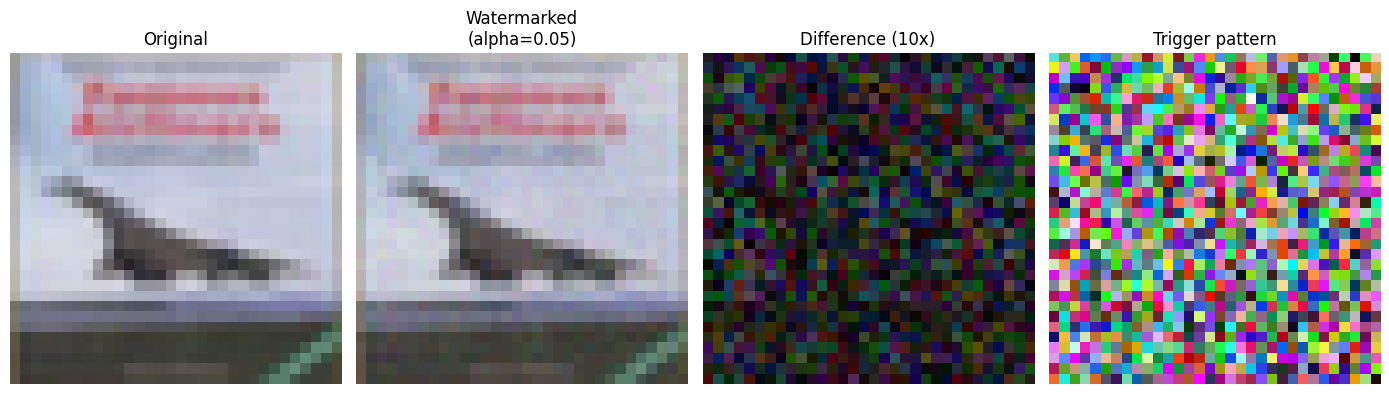

Saved to trigger_comparison_005.png


In [11]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from PIL import Image

sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))
from tools import TriggerAppending

data = datasets.CIFAR10(root='../data', train=False, download=False)
sample = Image.fromarray(data.data[3])

trigger = transforms.ToTensor()(Image.open('../triggers/hf_noise_trigger_32x32.png'))
alpha   = transforms.ToTensor()(Image.open('../triggers/alpha_noise_005.png'))

watermarked = TriggerAppending(trigger=trigger, alpha=alpha)(sample)

diff = np.abs(np.array(watermarked).astype(int) - np.array(sample).astype(int))
diff_amplified = (diff * 10).clip(0, 255).astype('uint8')
trigger_vis = np.array(trigger.permute(1, 2, 0) * 255, dtype='uint8')

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, img, title in zip(
    axes,
    [np.array(sample), np.array(watermarked), diff_amplified, trigger_vis],
    ['Original', 'Watermarked\n(alpha=0.05)', 'Difference (10x)', 'Trigger pattern'],
):
    ax.imshow(img, interpolation='nearest')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('trigger_comparison_005.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to trigger_comparison_005.png')

/tmp/ipykernel_34988/2524619232.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  trigger_vis = np.array(trigger.permute(1, 2, 0) * 255, dtype='uint8')


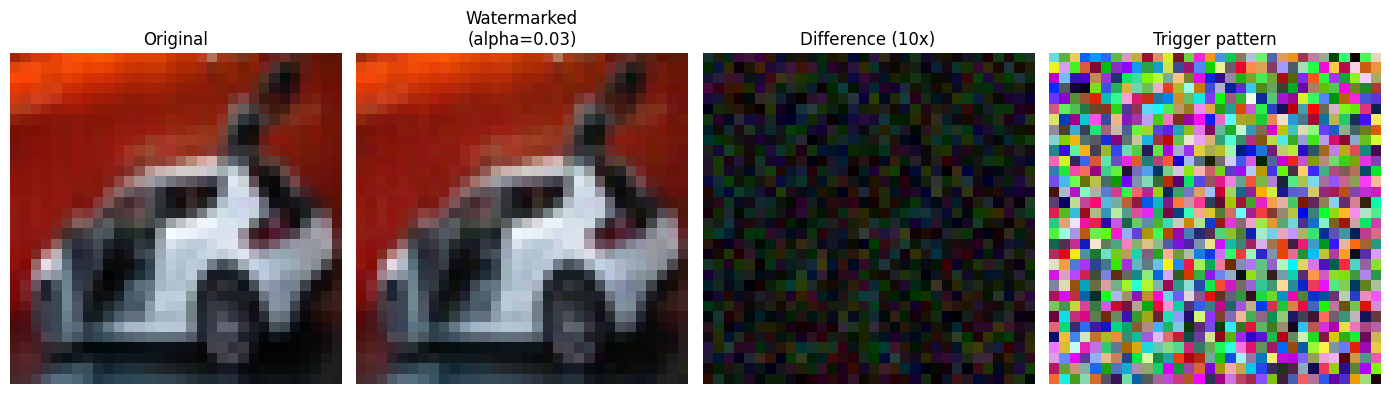

Saved to trigger_comparison_003.png


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from PIL import Image

sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))
from tools import TriggerAppending

data = datasets.CIFAR10(root='../data', train=False, download=False)
sample = Image.fromarray(data.data[3])

trigger = transforms.ToTensor()(Image.open('../triggers/hf_noise_trigger_32x32.png'))
alpha   = transforms.ToTensor()(Image.open('../triggers/alpha_noise_003.png'))

watermarked = TriggerAppending(trigger=trigger, alpha=alpha)(sample)

diff = np.abs(np.array(watermarked).astype(int) - np.array(sample).astype(int))
diff_amplified = (diff * 10).clip(0, 255).astype('uint8')
trigger_vis = np.array(trigger.permute(1, 2, 0) * 255, dtype='uint8')

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, img, title in zip(
    axes,
    [np.array(sample), np.array(watermarked), diff_amplified, trigger_vis],
    ['Original', 'Watermarked\n(alpha=0.03)', 'Difference (10x)', 'Trigger pattern'],
):
    ax.imshow(img, interpolation='nearest')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('trigger_comparison_003.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to trigger_comparison_003.png')